In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv("../data/salesAnalysis_cleaned.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Avg_Item_Price,Discount_Percentage,Cost_Price,Profit,Profit_Margin,Cart_Size,Engagement_Score,Pages_Per_Minute,Is_Delayed,Rating_Category
0,ORD_000001-1,CUST_00001,2023-05-28,40,Male,Ankara,Books,29.18,1,0.00,...,29.18,0.000000,20.426,8.754,0.300000,1,126,0.642857,1,Medium
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,...,506.35,0.214230,451.080,55.270,0.109154,1,112,0.571429,0,Low
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,...,332.82,0.000000,232.974,1431.126,0.860000,5,150,0.666667,1,Medium
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,...,55.09,0.205051,48.510,226.940,0.823888,5,208,0.812500,0,Medium
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,...,178.15,0.000000,124.705,409.745,0.766667,3,98,0.500000,0,Medium


In [5]:
df.drop(columns=["Order_ID", "Customer_ID"], inplace=True)

In [6]:

categorical_cols = df.select_dtypes(include='object').columns
numeric_cols= df.select_dtypes(include=['int64', 'float64']).columns


# Categorical Features Analysis


In [7]:
categorical_cols

Index(['Date', 'Gender', 'City', 'Product_Category', 'Payment_Method',
       'Device_Type', 'Rating_Category'],
      dtype='object')

In [9]:
df["Product_Category"].value_counts()

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64

In [11]:
for col in categorical_cols:
    print(col," :", df[col].nunique())

Date  : 450
Gender  : 3
City  : 10
Product_Category  : 8
Payment_Method  : 5
Device_Type  : 3
Rating_Category  : 3


In [12]:
df['Rating_Category'].value_counts()

Rating_Category
Medium    8521
High      6260
Low       2268
Name: count, dtype: int64

In [13]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card         6801
Debit Card          4321
Digital Wallet      3276
Bank Transfer       1763
Cash on Delivery     888
Name: count, dtype: int64

<Axes: xlabel='Product_Category', ylabel='count'>

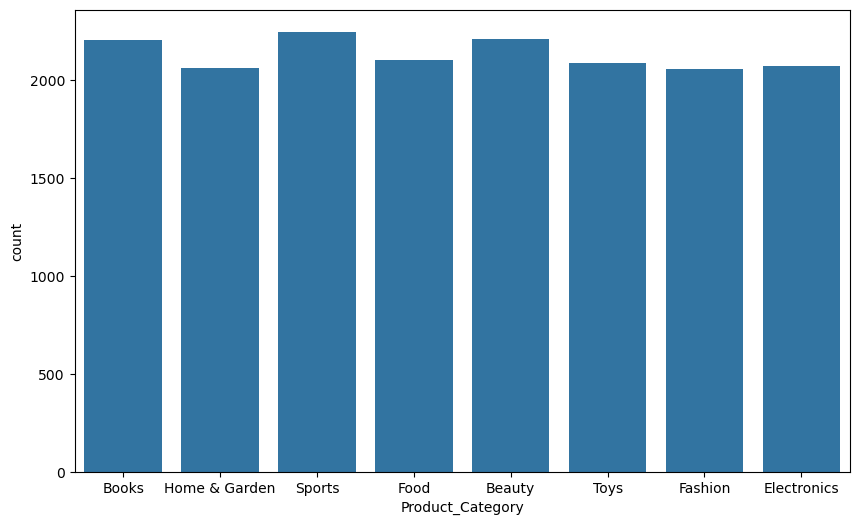

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x="Product_Category", data=df)


In [16]:
df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=False)

Product_Category
Electronics      10481897.65
Home & Garden     4023903.94
Sports            3205086.99
Fashion           1577035.70
Toys              1014237.53
Beauty             694437.02
Food               422054.65
Books              360399.11
Name: Total_Amount, dtype: float64

In [17]:
df.groupby("Product_Category")["Customer_Rating"].mean()

Product_Category
Beauty           3.921338
Books            3.881233
Electronics      3.898264
Fashion          3.887160
Food             3.862577
Home & Garden    3.930097
Sports           3.918149
Toys             3.895215
Name: Customer_Rating, dtype: float64

<Axes: xlabel='Device_Type', ylabel='Total_Amount'>

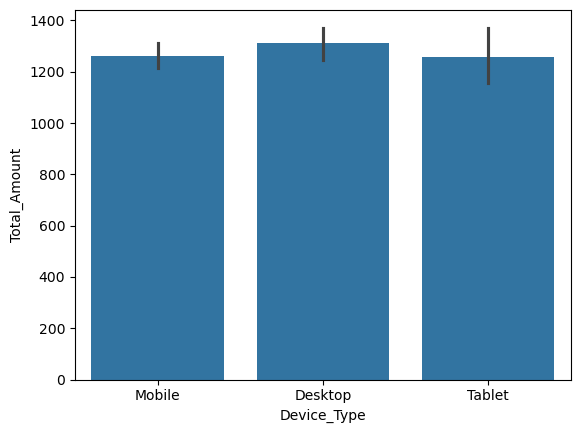

In [19]:
sns.barplot(x="Device_Type", y="Total_Amount", data=df)

In [20]:
df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False)

City
Istanbul     5646595.78
Ankara       3052443.10
Izmir        2651743.92
Bursa        2317028.10
Antalya      1661594.15
Gaziantep    1573422.25
Adana        1512320.19
Konya        1363152.80
Kayseri      1091658.53
Eskisehir     909093.77
Name: Total_Amount, dtype: float64

<Axes: xlabel='Payment_Method', ylabel='Product_Category'>

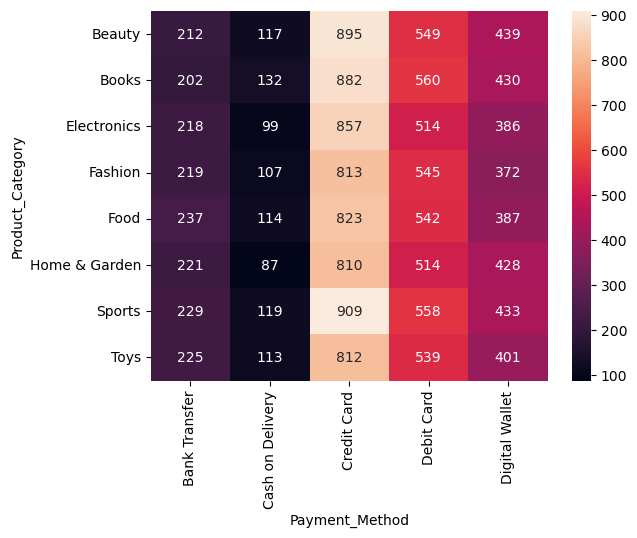

In [21]:
sns.heatmap(pd.crosstab(df["Product_Category"], df["Payment_Method"]), annot=True, fmt="d")

# 📊 Categorical Features – Key Insights & Business Meaning

## 🛍️ Product Category Distribution
### Insight:
Product categories are relatively evenly distributed, with slightly higher counts in categories like Sports and Beauty.

### Business Meaning:
The platform has a well-balanced product mix, indicating diversified demand across categories rather than reliance on a single segment.

---

## 💳 Payment Method Preferences
### Insight:
Credit Card is the most frequently used payment method across all product categories, followed by Debit Card and Digital Wallet, while Cash on Delivery is the least used.

### Business Meaning:
Customers show a strong preference for digital payment methods, indicating trust in online transactions and reduced dependency on offline payment options.

---

## 🛒 Category-wise Payment Behavior
### Insight:
Across all product categories, Credit Card usage consistently dominates, with similar patterns observed for Debit Card and Digital Wallet.

### Business Meaning:
Payment behavior is uniform across product categories, suggesting that payment preference is driven more by customer habit than product type.

---

## 📱 Device-wise Revenue Contribution
### Insight:
Desktop users generate the highest average transaction value, followed by Mobile and Tablet users.

### Business Meaning:
Users on desktops tend to make higher-value purchases, possibly due to better browsing experience or more deliberate buying behavior.

---

## 📊 Device Usage Patterns
### Insight:
Mobile and Tablet devices show slightly lower transaction values compared to the Desktop.

### Business Meaning:
Mobile users may exhibit more casual browsing or smaller purchases, highlighting the need for optimized mobile conversion strategies.

---

## 🔄 Category Engagement Consistency
### Insight:
All product categories show similar transaction volumes without extreme dominance or underperformance.

### Business Meaning:
Customer interest is evenly spread, indicating stable demand and reduced risk associated with category-specific fluctuations.

---

# Numerical Features Analysis


In [22]:
numeric_cols

Index(['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days',
       'Customer_Rating', 'Total_Sales', 'Avg_Item_Price',
       'Discount_Percentage', 'Cost_Price', 'Profit', 'Profit_Margin',
       'Cart_Size', 'Engagement_Score', 'Pages_Per_Minute', 'Is_Delayed'],
      dtype='object')

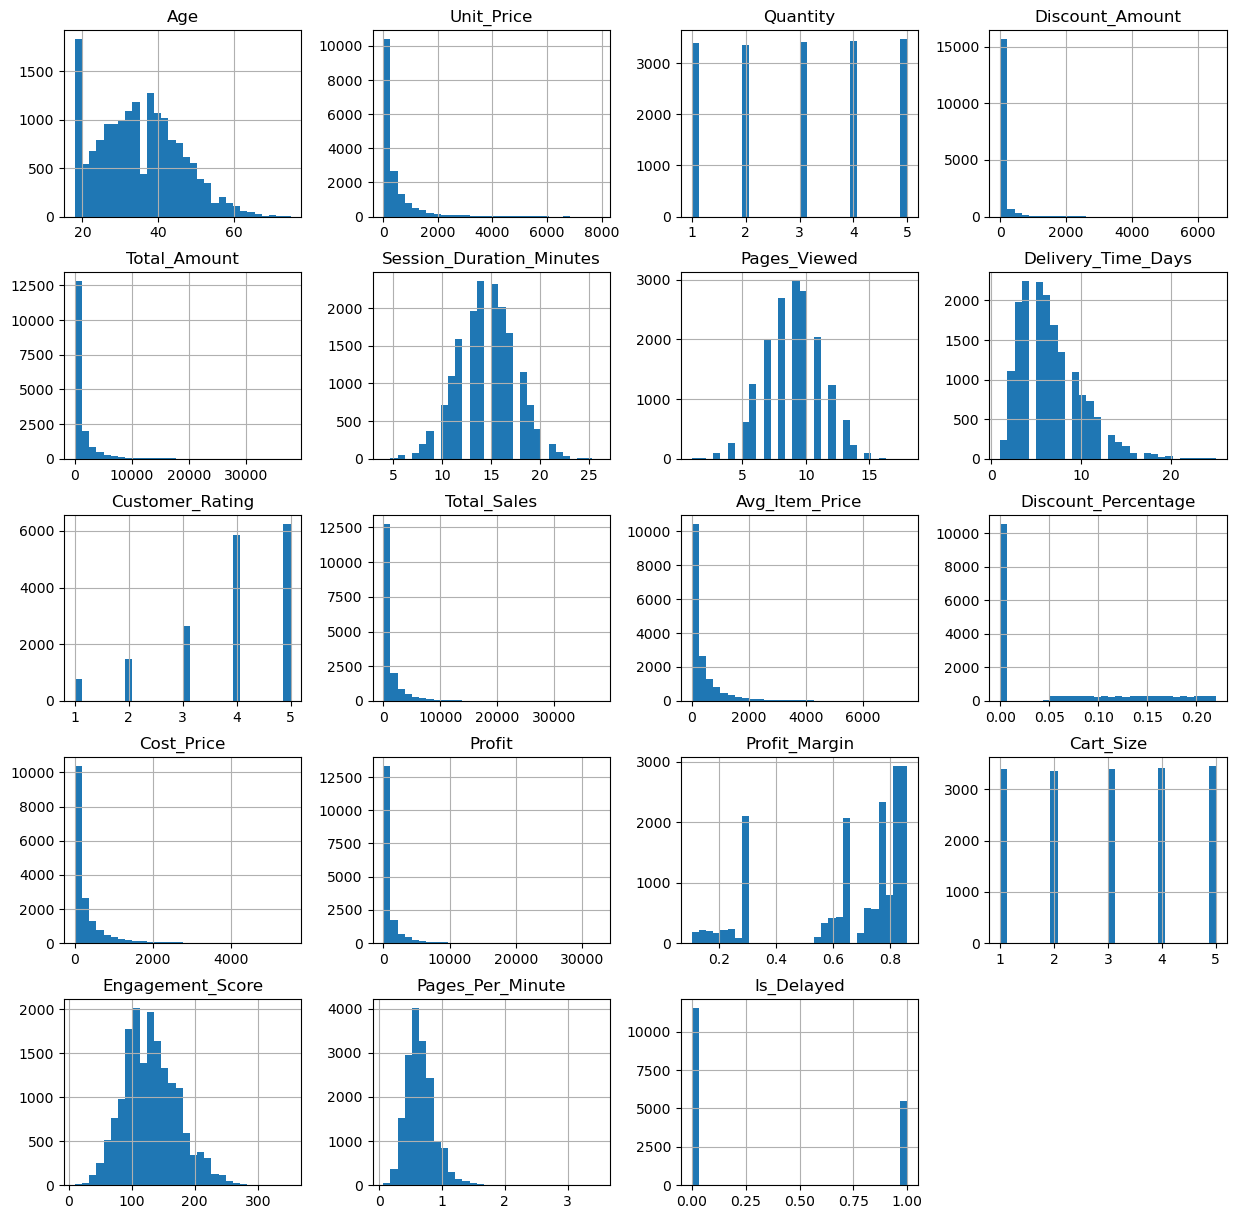

In [24]:
df[numeric_cols].hist(figsize=(15,15), bins=30)
plt.show()

<Axes: >

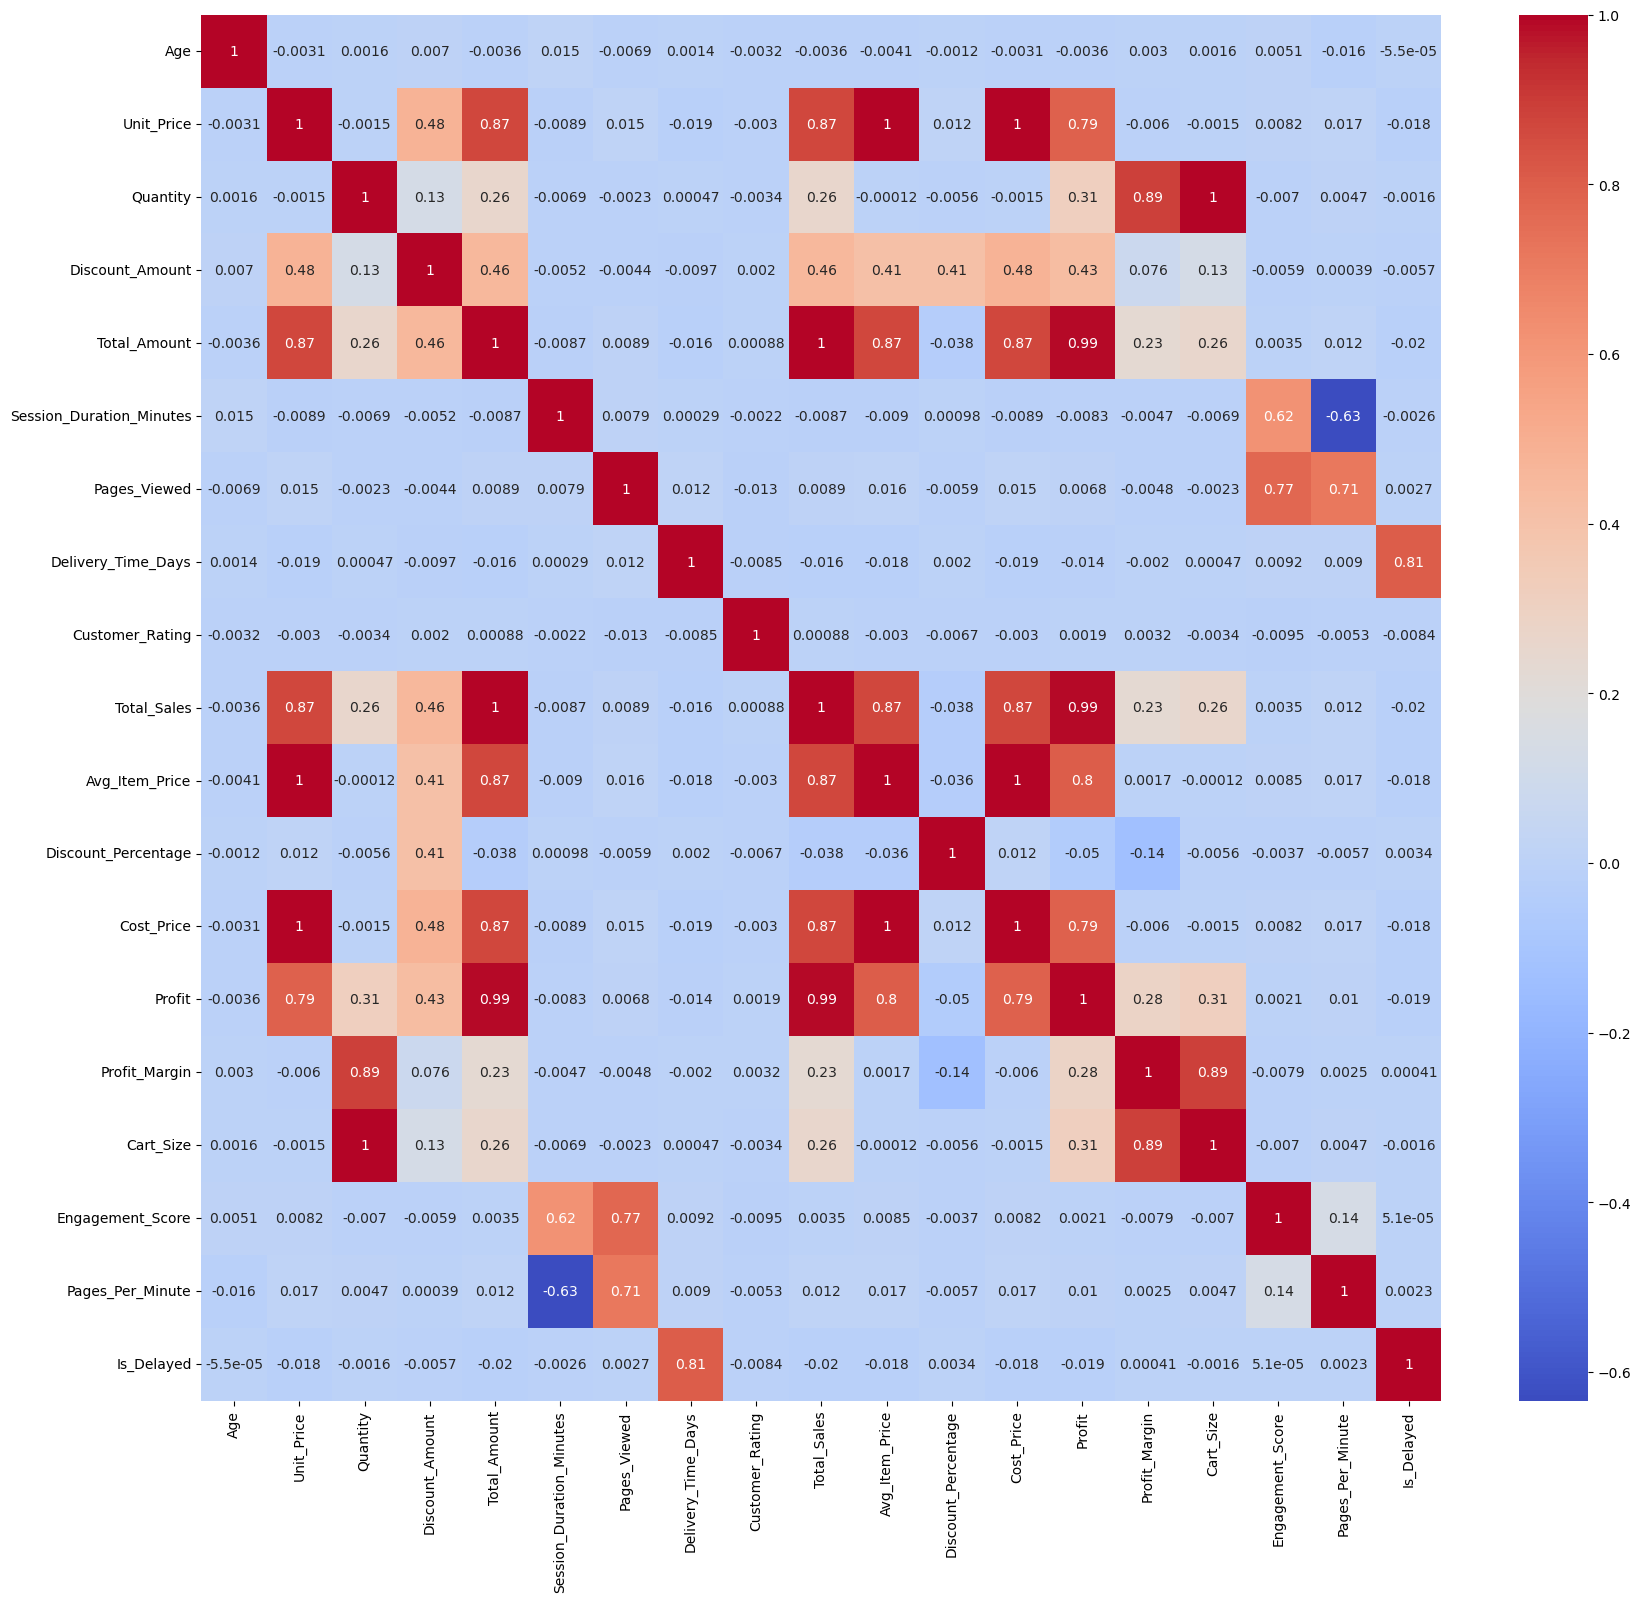

In [28]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(20,18))
sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='Quantity', ylabel='Total_Amount'>

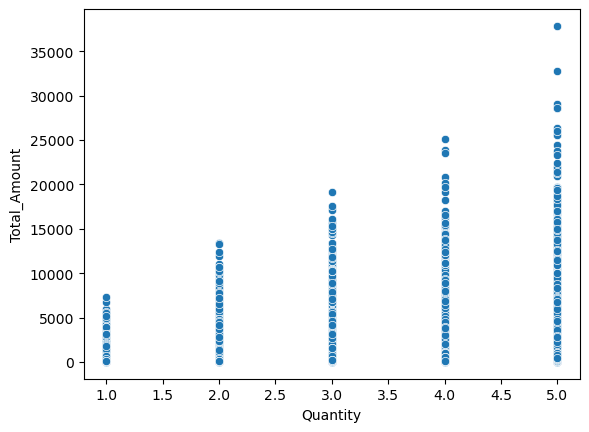

In [29]:
sns.scatterplot(x="Quantity", y="Total_Amount", data=df)

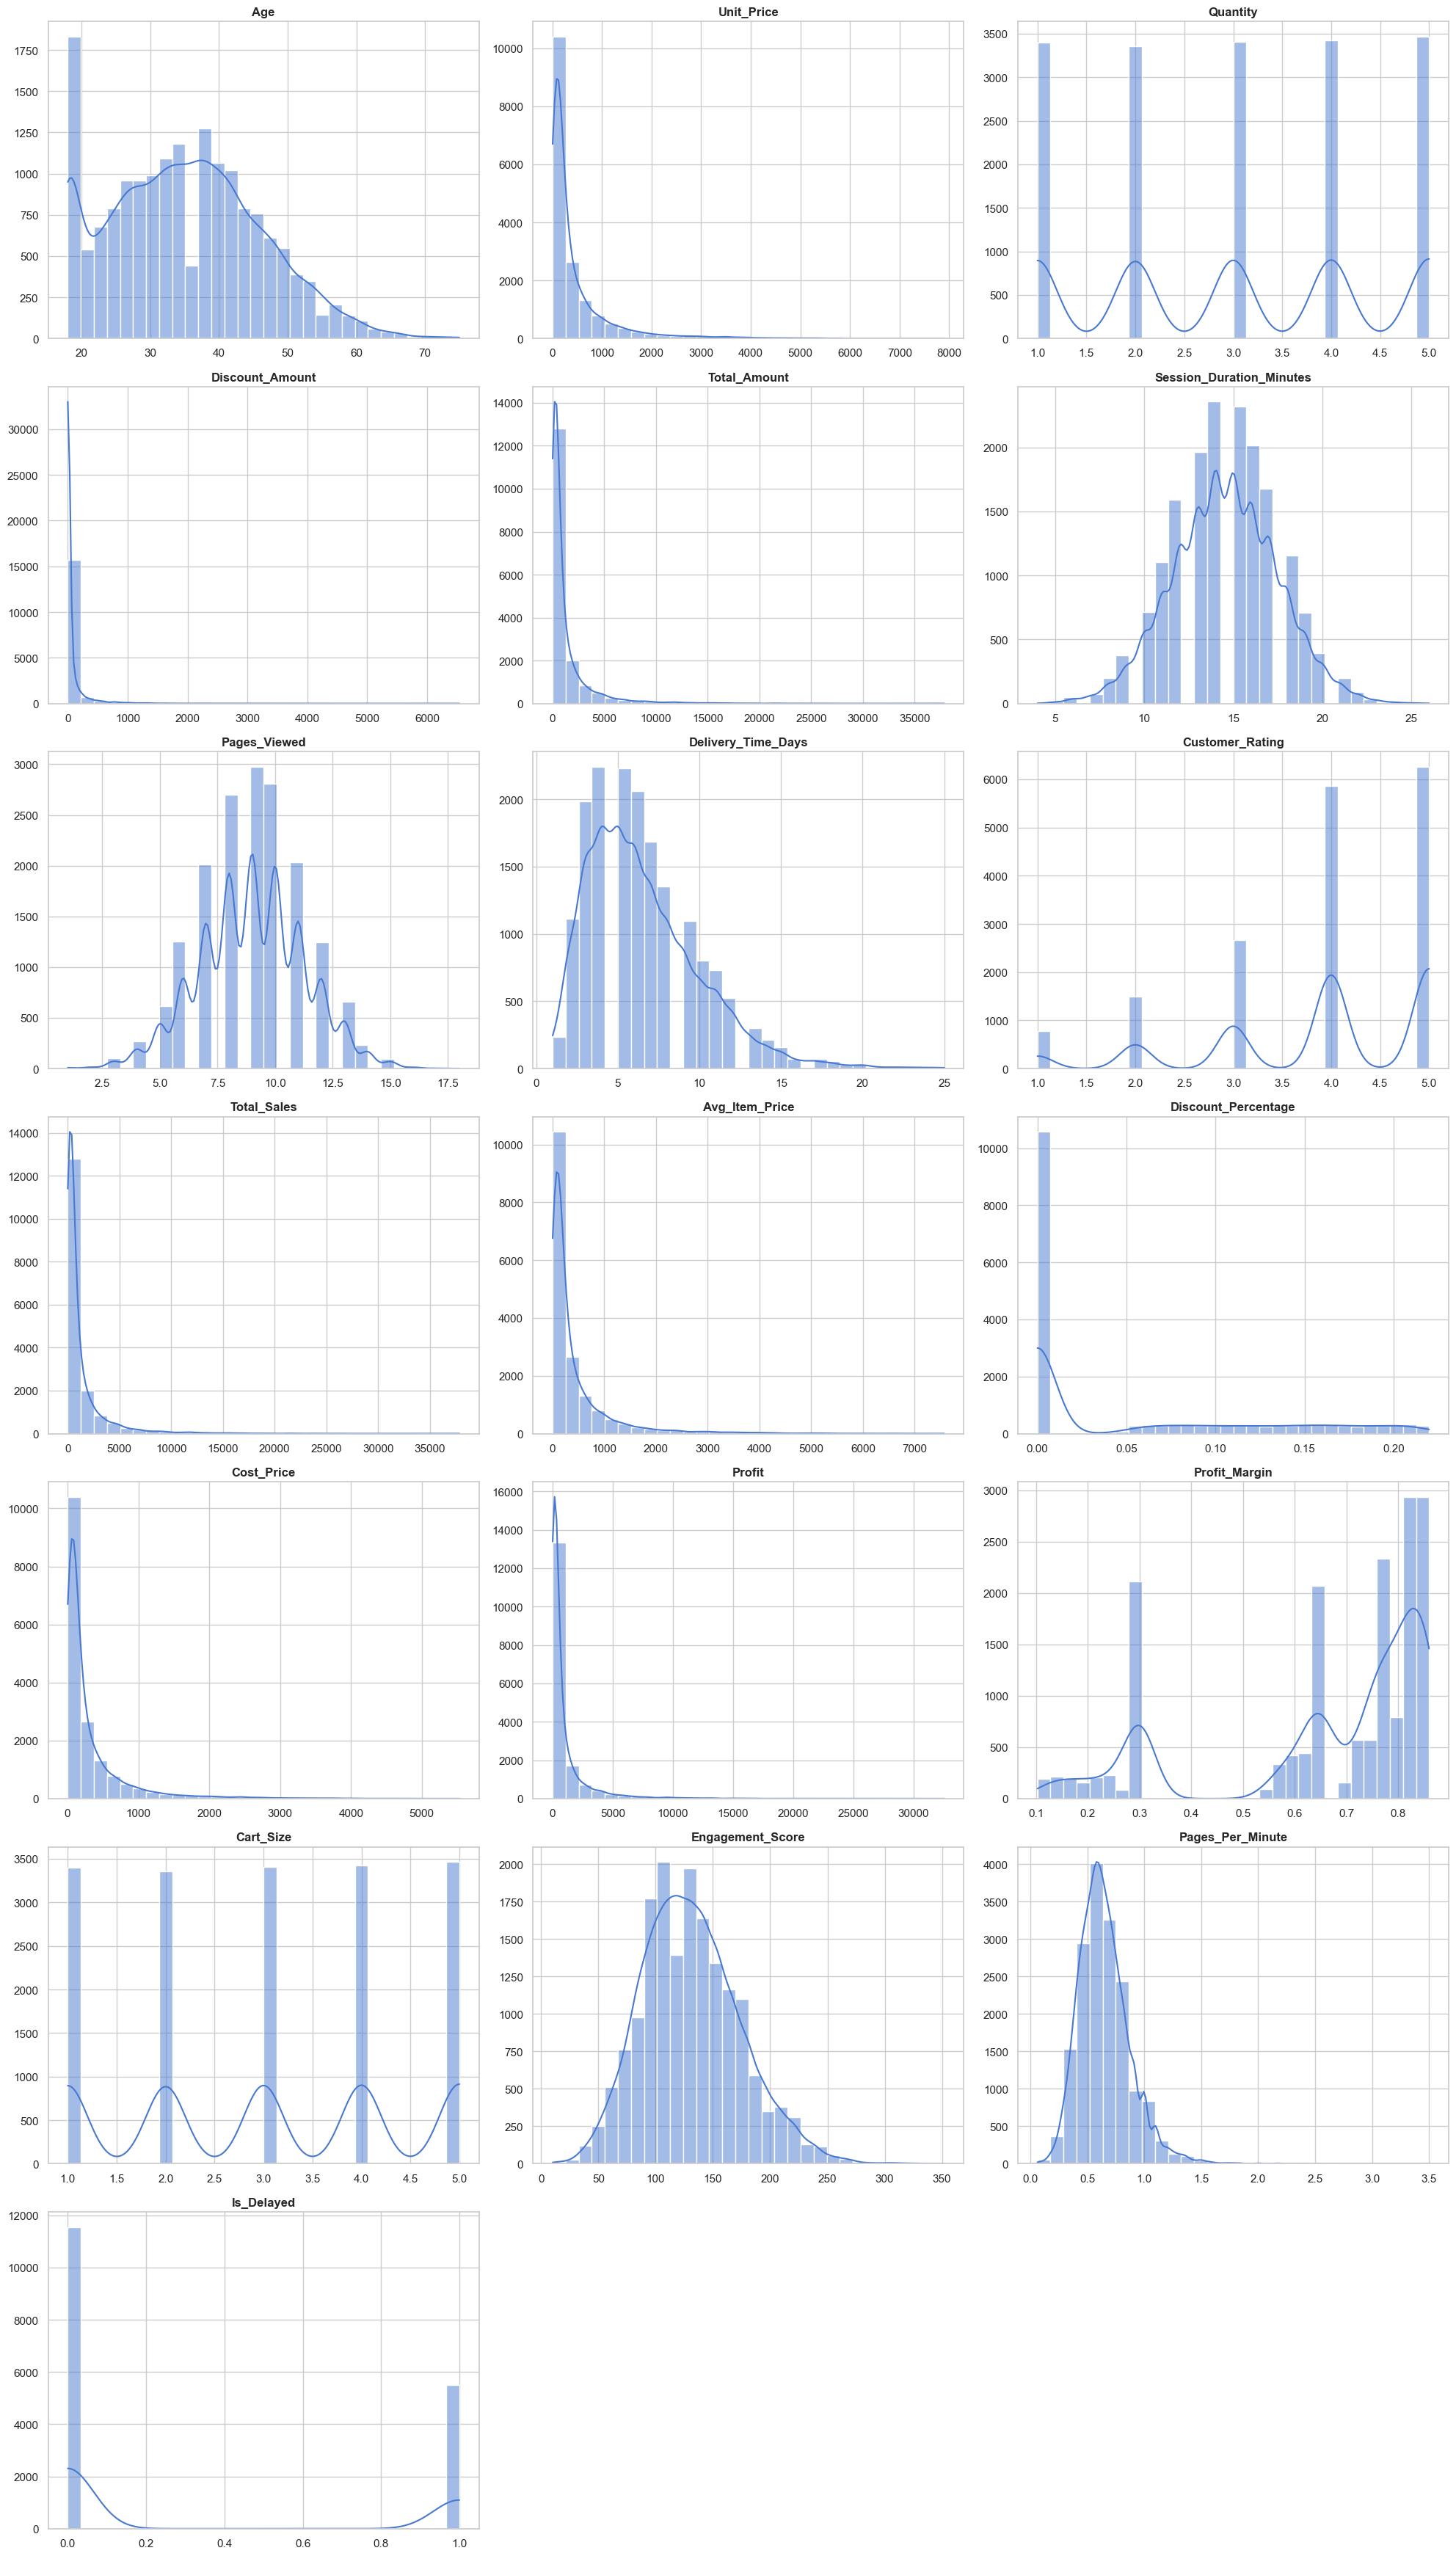

In [31]:
import math 
sns.set_theme(style="whitegrid", palette="muted")
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    
    axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Numerical Features – Key Insights & Business Meaning

## 🔥 Revenue & Pricing Patterns
### Insight:
Revenue-related features (`Total_Amount`, `Total_Sales`, `Unit_Price`, `Cost_Price`, `Profit`) show strong right-skewness.

### Business Meaning:
A small number of transactions contribute disproportionately to revenue, indicating a long-tail distribution where high-value customers or premium products drive significant sales.

---

## 📈 Customer Behavior Consistency
### Insight:
Features like `Age`, `Session_Duration_Minutes`, `Pages_Viewed`, and `Engagement_Score` follow approximately normal distributions.

### Business Meaning:
User behavior is relatively consistent and predictable, suggesting stable engagement patterns across the majority of customers.

---

## ⚠️ Discrete Customer Actions
### Insight:
`Customer_Rating`, `Quantity`, and `Cart_Size` are discrete with limited unique values.

### Business Meaning:
Customer interactions such as ratings and purchase quantities follow fixed patterns, reflecting standardized user behavior and decision-making.

---

## 💸 Discount Strategy
### Insight:
`Discount_Percentage` is concentrated near zero, while `Discount_Amount` is highly skewed.

### Business Meaning:
Discounts are applied selectively rather than broadly, indicating targeted promotional strategies instead of frequent discounting.

---

## 💰 Revenue Drivers
### Insight:
Strong positive relationships exist between `Quantity`, `Unit_Price`, and `Total_Amount`.

### Business Meaning:
Revenue is primarily driven by the number of items purchased and product pricing, highlighting key levers for increasing sales.

---

## 🔗 Feature Redundancy
### Insight:
`Total_Amount`, `Total_Sales`, and `Profit` are highly correlated.

### Business Meaning:
These metrics capture similar financial information, indicating redundancy and potential for simplification in analysis or modeling.

---

## 📊 User Engagement Patterns
### Insight:
`Pages_Viewed` strongly correlates with `Engagement_Score`, while faster browsing reduces session duration.

### Business Meaning:
Higher interaction depth leads to better engagement, whereas quick navigation may indicate lower user interest or intent.

---

## 🚚 Delivery Performance
### Insight:
`Delivery_Time_Days` strongly correlates with `Is_Delayed`.

### Business Meaning:
Delivery delays are predictable and closely tied to delivery duration, enabling operational improvements and delay mitigation strategies.

---

## 👥 Typical User Behavior
### Insight:
Most users exhibit moderate session duration and page views.

### Business Meaning:
The majority of users engage at an average level, indicating a balanced user base without extreme behavioral patterns.

---

## 🚨 Outlier Presence
### Insight:
Extreme values are present in revenue and pricing-related features.

### Business Meaning:
Outliers likely represent high-value customers or bulk purchases, which are critical for revenue but require separate analysis for accurate modeling.

---